In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.config import TRAIN_A, TRAIN_B, RESULTS_DIR, MODELS_DIR

print("Training Set A:", TRAIN_A)
print("Training Set B:", TRAIN_B)
print("Results:", RESULTS_DIR)
print("Models:", MODELS_DIR)

Training Set A: C:\TwinSepsis\dataset\physionet.org\files\challenge-2019\1.0.0\training\training_setA
Training Set B: C:\TwinSepsis\dataset\physionet.org\files\challenge-2019\1.0.0\training\training_setB
Results: C:\TwinSepsis\results
Models: C:\TwinSepsis\models


In [2]:
train_ids = pd.read_csv(
    RESULTS_DIR / "train_patient_ids.csv"
)["patient_id"].tolist()

val_ids = pd.read_csv(
    RESULTS_DIR / "val_patient_ids.csv"
)["patient_id"].tolist()

test_ids = pd.read_csv(
    RESULTS_DIR / "test_patient_ids.csv"
)["patient_id"].tolist()

print("Training patients:", len(train_ids))
print("Validation patients:", len(val_ids))
print("Test patients:", len(test_ids))

Training patients: 28235
Validation patients: 6050
Test patients: 6051


In [3]:
all_patient_files = {}

for file_path in TRAIN_A.glob("*.psv"):
    all_patient_files[file_path.stem] = file_path

for file_path in TRAIN_B.glob("*.psv"):
    all_patient_files[file_path.stem] = file_path

print("Total patient files:", len(all_patient_files))

print(
    "Missing train:",
    sum(pid not in all_patient_files for pid in train_ids)
)

print(
    "Missing validation:",
    sum(pid not in all_patient_files for pid in val_ids)
)

print(
    "Missing test:",
    sum(pid not in all_patient_files for pid in test_ids)
)

Total patient files: 40336
Missing train: 0
Missing validation: 0
Missing test: 0


In [4]:
TARGET = "SepsisLabel"

# These are the same 40 features used for XGBoost.
DROP_COLUMNS = [TARGET, "patient_id"]

FEATURE_COLUMNS = [
    col for col in pd.read_csv(
        all_patient_files[train_ids[0]],
        sep="|",
        nrows=1
    ).columns
    if col not in DROP_COLUMNS
]

print("Number of features:", len(FEATURE_COLUMNS))
print("Features:")
print(FEATURE_COLUMNS)


def load_split(patient_ids, split_name):
    frames = []

    for i, pid in enumerate(patient_ids):
        file_path = all_patient_files[pid]

        df = pd.read_csv(file_path, sep="|")

        # Keep the patient ID only for tracking.
        # It will NOT be used as a model feature.
        df["patient_id"] = pid

        frames.append(df)

        if (i + 1) % 2000 == 0:
            print(
                f"{split_name}: "
                f"loaded {i + 1:,} / {len(patient_ids):,} patients"
            )

    data = pd.concat(frames, ignore_index=True)

    print(f"\n{split_name} complete")
    print("Rows:", f"{len(data):,}")
    print("Columns:", len(data.columns))

    return data


train_df = load_split(train_ids, "Training")

Number of features: 40
Features:
['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS']
Training: loaded 2,000 / 28,235 patients
Training: loaded 4,000 / 28,235 patients
Training: loaded 6,000 / 28,235 patients
Training: loaded 8,000 / 28,235 patients
Training: loaded 10,000 / 28,235 patients
Training: loaded 12,000 / 28,235 patients
Training: loaded 14,000 / 28,235 patients
Training: loaded 16,000 / 28,235 patients
Training: loaded 18,000 / 28,235 patients
Training: loaded 20,000 / 28,235 patients
Training: loaded 22,000 / 28,235 patients
Training: loaded 24,000 / 28,235 patients
Training: loaded 26,000 / 28,235 patients
Training: loade

In [5]:
X_train = train_df[FEATURE_COLUMNS].copy()
y_train = train_df[TARGET].astype(int).copy()

# Clean infinite values
X_train = X_train.replace([np.inf, -np.inf], np.nan)

# Use float32 to reduce memory usage
X_train = X_train.astype(np.float32)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nTarget distribution:")
print(y_train.value_counts())

print("\nPositive rate:")
print(f"{y_train.mean() * 100:.3f}%")

X_train shape: (1086436, 40)
y_train shape: (1086436,)

Target distribution:
SepsisLabel
0    1066876
1      19560
Name: count, dtype: int64

Positive rate:
1.800%


In [6]:
val_df = load_split(val_ids, "Validation")

X_val = val_df[FEATURE_COLUMNS].copy()
y_val = val_df[TARGET].astype(int).copy()

X_val = X_val.replace([np.inf, -np.inf], np.nan)
X_val = X_val.astype(np.float32)

print("\nValidation shape:", X_val.shape)

print("\nValidation target distribution:")
print(y_val.value_counts())

print("\nValidation positive rate:")
print(f"{y_val.mean() * 100:.3f}%")

Validation: loaded 2,000 / 6,050 patients
Validation: loaded 4,000 / 6,050 patients
Validation: loaded 6,000 / 6,050 patients

Validation complete
Rows: 231,472
Columns: 42

Validation shape: (231472, 40)

Validation target distribution:
SepsisLabel
0    227310
1      4162
Name: count, dtype: int64

Validation positive rate:
1.798%


In [7]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42,
    max_features="sqrt",
    min_samples_leaf=2
)

print("Starting Random Forest training...")

rf_model.fit(
    X_train,
    y_train
)

print("\nRandom Forest training complete.")
print("Number of trees:", len(rf_model.estimators_))

Starting Random Forest training...

Random Forest training complete.
Number of trees: 300


In [8]:
# Validation predictions
rf_val_proba = rf_model.predict_proba(X_val)[:, 1]
rf_val_pred = (rf_val_proba >= 0.5).astype(int)

# Metrics
rf_val_accuracy = accuracy_score(y_val, rf_val_pred)
rf_val_precision = precision_score(y_val, rf_val_pred, zero_division=0)
rf_val_recall = recall_score(y_val, rf_val_pred, zero_division=0)
rf_val_f1 = f1_score(y_val, rf_val_pred, zero_division=0)
rf_val_auc = roc_auc_score(y_val, rf_val_proba)

print("===== RANDOM FOREST VALIDATION =====")
print(f"Accuracy : {rf_val_accuracy:.4f}")
print(f"Precision: {rf_val_precision:.4f}")
print(f"Recall   : {rf_val_recall:.4f}")
print(f"F1 Score : {rf_val_f1:.4f}")
print(f"ROC-AUC  : {rf_val_auc:.4f}")

print("\n===== CONFUSION MATRIX =====")

rf_val_cm = confusion_matrix(y_val, rf_val_pred)

rf_val_cm_df = pd.DataFrame(
    rf_val_cm,
    index=["Actual: No Sepsis", "Actual: Sepsis"],
    columns=["Predicted: No Sepsis", "Predicted: Sepsis"]
)

display(rf_val_cm_df)

print("\n===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_val,
        rf_val_pred,
        target_names=["No Sepsis", "Sepsis"],
        zero_division=0
    )
)

===== RANDOM FOREST VALIDATION =====
Accuracy : 0.9803
Precision: 0.0738
Recall   : 0.0084
F1 Score : 0.0151
ROC-AUC  : 0.7631

===== CONFUSION MATRIX =====


,Predicted: No Sepsis,Predicted: Sepsis
Actual: No Sepsis,226871,439
Actual: Sepsis,4127,35



===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

   No Sepsis       0.98      1.00      0.99    227310
      Sepsis       0.07      0.01      0.02      4162

    accuracy                           0.98    231472
   macro avg       0.53      0.50      0.50    231472
weighted avg       0.97      0.98      0.97    231472



In [9]:
thresholds = np.arange(0.01, 0.51, 0.01)

threshold_results = []

for threshold in thresholds:

    predictions = (rf_val_proba >= threshold).astype(int)

    precision = precision_score(
        y_val,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        predictions,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

print("===== RANDOM FOREST THRESHOLD ANALYSIS =====")

display(
    threshold_df.style.format({
        "Threshold": "{:.2f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)

# Best threshold according to F1
best_f1_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print("\n===== BEST F1 THRESHOLD =====")
print(best_f1_row)

===== RANDOM FOREST THRESHOLD ANALYSIS =====


,Threshold,Precision,Recall,F1
0,0.01,0.0222,0.9553,0.0434
1,0.02,0.0271,0.8919,0.0525
2,0.03,0.0323,0.8340,0.0622
3,0.04,0.0371,0.7645,0.0708
4,0.05,0.0418,0.6970,0.0788
5,0.06,0.0465,0.6398,0.0868
6,0.07,0.0503,0.5793,0.0925
7,0.08,0.0534,0.5209,0.0969
8,0.09,0.0569,0.4753,0.1016
9,0.10,0.0598,0.4349,0.1052



===== BEST F1 THRESHOLD =====
Threshold    0.170000
Precision    0.073606
Recall       0.255887
F1           0.114326
Name: 16, dtype: float64


In [10]:
# Select threshold based ONLY on validation data
best_rf_threshold = float(best_f1_row["Threshold"])

print("Selected Random Forest threshold:", best_rf_threshold)
print("Validation F1:", best_f1_row["F1"])
print("Validation precision:", best_f1_row["Precision"])
print("Validation recall:", best_f1_row["Recall"])

Selected Random Forest threshold: 0.17
Validation F1: 0.1143255863882776
Validation precision: 0.07360563964337549
Validation recall: 0.25588659298414224


In [11]:
test_df = load_split(test_ids, "Test")

X_test = test_df[FEATURE_COLUMNS].copy()
y_test = test_df[TARGET].astype(int).copy()

X_test = X_test.replace([np.inf, -np.inf], np.nan)
X_test = X_test.astype(np.float32)

print("\nTest shape:", X_test.shape)

print("\nTest target distribution:")
print(y_test.value_counts())

print("\nTest positive rate:")
print(f"{y_test.mean() * 100:.3f}%")

Test: loaded 2,000 / 6,051 patients
Test: loaded 4,000 / 6,051 patients
Test: loaded 6,000 / 6,051 patients

Test complete
Rows: 234,302
Columns: 42

Test shape: (234302, 40)

Test target distribution:
SepsisLabel
0    230108
1      4194
Name: count, dtype: int64

Test positive rate:
1.790%


In [12]:
# Test probabilities
rf_test_proba = rf_model.predict_proba(X_test)[:, 1]

# IMPORTANT:
# Use the threshold selected from validation only.
rf_test_pred = (
    rf_test_proba >= best_rf_threshold
).astype(int)

# Metrics
rf_test_accuracy = accuracy_score(y_test, rf_test_pred)
rf_test_precision = precision_score(
    y_test,
    rf_test_pred,
    zero_division=0
)
rf_test_recall = recall_score(
    y_test,
    rf_test_pred,
    zero_division=0
)
rf_test_f1 = f1_score(
    y_test,
    rf_test_pred,
    zero_division=0
)
rf_test_auc = roc_auc_score(
    y_test,
    rf_test_proba
)

print("===== RANDOM FOREST TEST RESULTS =====")

print(f"Threshold: {best_rf_threshold:.2f}")
print(f"Accuracy : {rf_test_accuracy:.4f}")
print(f"Precision: {rf_test_precision:.4f}")
print(f"Recall   : {rf_test_recall:.4f}")
print(f"F1 Score : {rf_test_f1:.4f}")
print(f"ROC-AUC  : {rf_test_auc:.4f}")

print("\n===== CONFUSION MATRIX =====")

rf_test_cm = confusion_matrix(
    y_test,
    rf_test_pred
)

rf_test_cm_df = pd.DataFrame(
    rf_test_cm,
    index=["Actual: No Sepsis", "Actual: Sepsis"],
    columns=["Predicted: No Sepsis", "Predicted: Sepsis"]
)

display(rf_test_cm_df)

print("\n===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        rf_test_pred,
        target_names=["No Sepsis", "Sepsis"],
        zero_division=0
    )
)

===== RANDOM FOREST TEST RESULTS =====
Threshold: 0.17
Accuracy : 0.9299
Precision: 0.0908
Recall   : 0.3238
F1 Score : 0.1418
ROC-AUC  : 0.7815

===== CONFUSION MATRIX =====


,Predicted: No Sepsis,Predicted: Sepsis
Actual: No Sepsis,216512,13596
Actual: Sepsis,2836,1358



===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

   No Sepsis       0.99      0.94      0.96    230108
      Sepsis       0.09      0.32      0.14      4194

    accuracy                           0.93    234302
   macro avg       0.54      0.63      0.55    234302
weighted avg       0.97      0.93      0.95    234302



In [13]:
# ============================================================
# Save Random Forest model and final test results
# ============================================================

import joblib

# ------------------------------------------------------------
# 1. Save trained Random Forest model
# ------------------------------------------------------------

rf_model_path = MODELS_DIR / "random_forest_baseline.joblib"

joblib.dump(
    rf_model,
    rf_model_path
)

# ------------------------------------------------------------
# 2. Save test metrics
# ------------------------------------------------------------

rf_test_metrics = pd.DataFrame([{
    "model": "RandomForest_baseline",
    "n_estimators": len(rf_model.estimators_),
    "threshold": best_rf_threshold,
    "test_auc": rf_test_auc,
    "test_accuracy": rf_test_accuracy,
    "test_precision": rf_test_precision,
    "test_recall": rf_test_recall,
    "test_f1": rf_test_f1,
    "test_rows": len(y_test),
    "test_positive_samples": int(y_test.sum()),
    "test_negative_samples": int((y_test == 0).sum())
}])

rf_metrics_path = RESULTS_DIR / "random_forest_test_metrics.csv"

rf_test_metrics.to_csv(
    rf_metrics_path,
    index=False
)

# ------------------------------------------------------------
# 3. Save confusion matrix
# ------------------------------------------------------------

rf_confusion_path = (
    RESULTS_DIR / "random_forest_test_confusion_matrix.csv"
)

rf_test_cm_df.to_csv(
    rf_confusion_path
)

# ------------------------------------------------------------
# 4. Display saved results
# ------------------------------------------------------------

print("Random Forest model saved to:")
print(rf_model_path)

print("\nRandom Forest metrics saved to:")
print(rf_metrics_path)

print("\nRandom Forest confusion matrix saved to:")
print(rf_confusion_path)

print("\n===== FINAL RANDOM FOREST TEST METRICS =====")

display(
    rf_test_metrics.style.format({
        "threshold": "{:.2f}",
        "test_auc": "{:.4f}",
        "test_accuracy": "{:.4f}",
        "test_precision": "{:.4f}",
        "test_recall": "{:.4f}",
        "test_f1": "{:.4f}"
    })
)

Random Forest model saved to:
C:\TwinSepsis\models\random_forest_baseline.joblib

Random Forest metrics saved to:
C:\TwinSepsis\results\random_forest_test_metrics.csv

Random Forest confusion matrix saved to:
C:\TwinSepsis\results\random_forest_test_confusion_matrix.csv

===== FINAL RANDOM FOREST TEST METRICS =====


,model,n_estimators,threshold,test_auc,test_accuracy,test_precision,test_recall,test_f1,test_rows,test_positive_samples,test_negative_samples
0,RandomForest_baseline,300,0.17,0.7815,0.9299,0.0908,0.3238,0.1418,234302,4194,230108


              RANDOM FOREST TEST RESULTS


,Metric,Test
0,ROC-AUC,0.7815
1,Accuracy,0.9299
2,Precision,0.0908
3,Recall,0.3238
4,F1 Score,0.1418



TEST CONFUSION MATRIX


,Predicted: No Sepsis,Predicted: Sepsis
Actual: No Sepsis,216512,13596
Actual: Sepsis,2836,1358


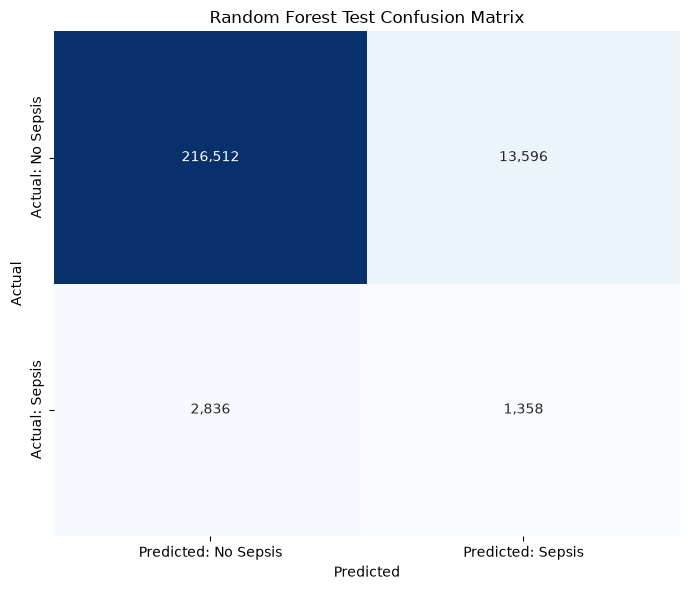

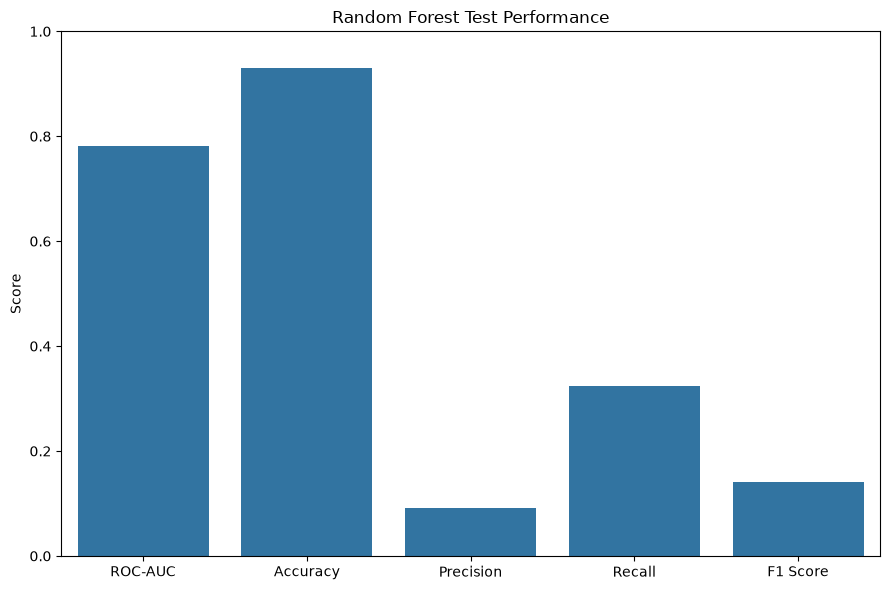


THRESHOLD SELECTION


,Selection,Value
0,Validation-selected threshold,0.1700
1,Validation F1,0.1143
2,Validation precision,0.0736
3,Validation recall,0.2559


In [14]:
# ============================================================
# RANDOM FOREST — RESULTS VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ------------------------------------------------------------
# 1. Random Forest test metrics table
# ------------------------------------------------------------

rf_results_df = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Test": [
        rf_test_auc,
        rf_test_accuracy,
        rf_test_precision,
        rf_test_recall,
        rf_test_f1
    ]
})

print("============================================================")
print("              RANDOM FOREST TEST RESULTS")
print("============================================================")

display(
    rf_results_df.style
    .format({"Test": "{:.4f}"})
    .set_caption("Random Forest Test Performance")
)


# ------------------------------------------------------------
# 2. Confusion matrix
# ------------------------------------------------------------

print("\nTEST CONFUSION MATRIX")

display(rf_test_cm_df)


# ------------------------------------------------------------
# 3. Confusion matrix heatmap
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

sns.heatmap(
    rf_test_cm_df,
    annot=True,
    fmt=",",
    cmap="Blues",
    cbar=False
)

plt.title("Random Forest Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Random Forest performance graph
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.barplot(
    data=rf_results_df,
    x="Metric",
    y="Test"
)

plt.ylim(0, 1)
plt.title("Random Forest Test Performance")
plt.xlabel("")
plt.ylabel("Score")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Threshold information
# ------------------------------------------------------------

threshold_summary = pd.DataFrame({
    "Selection": [
        "Validation-selected threshold",
        "Validation F1",
        "Validation precision",
        "Validation recall"
    ],
    "Value": [
        best_rf_threshold,
        best_f1_row["F1"],
        best_f1_row["Precision"],
        best_f1_row["Recall"]
    ]
})

print("\nTHRESHOLD SELECTION")

display(
    threshold_summary.style.format({
        "Value": "{:.4f}"
    })
)